In [14]:
import random
from typing import List, Tuple

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

N = 16        # start small (works everywhere). Increase later: 32, 64, 128...
SEED = 42
SHOTS = 1     # BB84 is one transmission per qubit

In [15]:
def gen_bits_bases(n: int, seed: int) -> Tuple[List[int], List[int], List[int]]:
    """
    Returns:
      alice_bits: 0/1
      alice_bases: 0(Z) or 1(X)
      bob_bases: 0(Z) or 1(X)
    """
    rng = random.Random(seed)
    alice_bits = [rng.randint(0, 1) for _ in range(n)]
    alice_bases = [rng.randint(0, 1) for _ in range(n)]
    bob_bases = [rng.randint(0, 1) for _ in range(n)]
    return alice_bits, alice_bases, bob_bases

In [16]:
def build_bb84_circuit(alice_bits, alice_bases, bob_bases) -> QuantumCircuit:
    n = len(alice_bits)
    qc = QuantumCircuit(n, n)  # n qubits, n classical bits

    # Alice prepares qubits
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:      # X basis
            qc.h(i)

    # Bob measures
    for i in range(n):
        if bob_bases[i] == 1:        # X basis measurement
            qc.h(i)
        qc.measure(i, i)

    return qc

In [17]:
def run_and_get_bob_bits(qc: QuantumCircuit, shots: int, seed: int) -> List[int]:
    # Unconstrained simulator: no coupling map limit
    sim = AerSimulator(seed_simulator=seed)

    tqc = transpile(qc, backend=sim, optimization_level=0, seed_transpiler=seed)
    result = sim.run(tqc, shots=shots).result()

    counts = result.get_counts()
    bitstring = max(counts, key=counts.get)  # most frequent outcome

    # Qiskit prints bits MSB..LSB; classical bit 0 is rightmost.
    bob_bits = [int(b) for b in bitstring[::-1]]
    return bob_bits

In [18]:
def sift(alice_bits, bob_bits, alice_bases, bob_bases):
    kept = [i for i in range(len(alice_bits)) if alice_bases[i] == bob_bases[i]]
    alice_key = [alice_bits[i] for i in kept]
    bob_key = [bob_bits[i] for i in kept]
    return kept, alice_key, bob_key

In [19]:
alice_bits, alice_bases, bob_bases = gen_bits_bases(N, SEED)
qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases)
bob_bits = run_and_get_bob_bits(qc, shots=SHOTS, seed=SEED)

kept, alice_key, bob_key = sift(alice_bits, bob_bits, alice_bases, bob_bases)

print("Alice bits: ", alice_bits)
print("Alice bases:", alice_bases)
print("Bob bases:  ", bob_bases)
print("Kept idx:   ", kept)
print()
print("Alice sifted key:", alice_key)
print("Bob sifted key:  ", bob_key)
print("Keys match?:     ", alice_key == bob_key)
print("Retention rate:  ", len(kept) / N)

Alice bits:  [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Alice bases: [1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0]
Bob bases:   [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0]
Kept idx:    [0, 2, 5, 6, 8, 10, 12, 13, 14, 15]

Alice sifted key: [0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
Bob sifted key:   [0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
Keys match?:      True
Retention rate:   0.625


In [20]:
assert len(kept) > 0, "No sifted bits retained; increase N."
assert alice_key == bob_key, "In ideal simulator, sifted keys should match."
print({"step_1": "passed"})

{'step_1': 'passed'}


In [23]:
import pandas as pd

df = pd.DataFrame({
    "Index": list(range(N)),
    "Alice Bit": alice_bits,
    "Alice Basis": alice_bases,
    "Bob Basis": bob_bases,
    "Basis Match": [alice_bases[i] == bob_bases[i] for i in range(N)],
})


,Index,Alice Bit,Alice Basis,Bob Basis,Basis Match
0,0,0,1,1,True
1,1,0,0,1,False
2,2,1,1,1,True
3,3,0,1,0,False
4,4,0,0,1,False
5,5,0,0,0,True
6,6,0,1,1,True
7,7,0,1,0,False
8,8,1,1,1,True
9,9,0,0,1,False


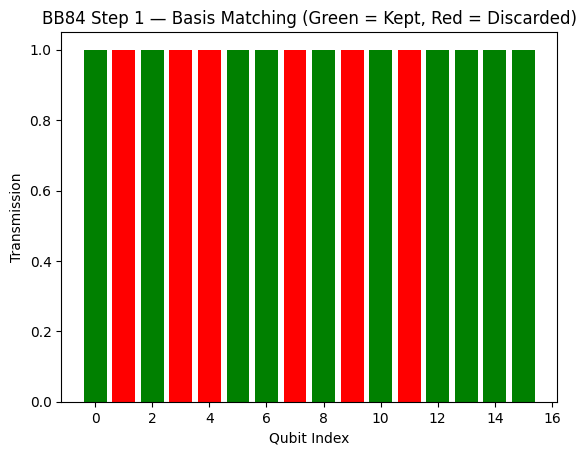

In [24]:
import matplotlib.pyplot as plt

basis_match = [alice_bases[i] == bob_bases[i] for i in range(N)]

colors = ["green" if m else "red" for m in basis_match]

plt.figure()
plt.bar(range(N), [1]*N, color=colors)

plt.title("BB84 Step 1 — Basis Matching (Green = Kept, Red = Discarded)")
plt.xlabel("Qubit Index")
plt.ylabel("Transmission")
plt.show()

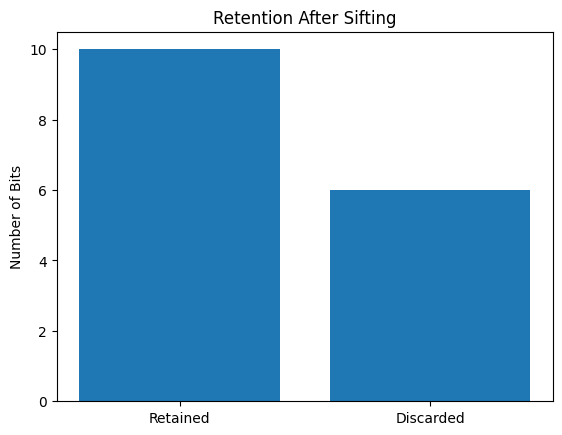

Retention Rate: 0.625


In [25]:
retention_rate = len(kept) / N

plt.figure()
plt.bar(["Retained", "Discarded"], 
        [len(kept), N - len(kept)])

plt.title("Retention After Sifting")
plt.ylabel("Number of Bits")
plt.show()

print("Retention Rate:", retention_rate)

In [29]:
# Checking the code on the hardware 
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_cloud",          # IBM Quantum Platform (IBM Cloud)
    token="ApiKey-f204b0a9-a517-45f7-8ed5-e0583bd36169", # <-- paste your token here
    set_as_default=True,
    overwrite=True,
)
print("Saved IBM Runtime account.")

Saved IBM Runtime account.


In [30]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()  # loads the default saved account

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=16)
backend

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'

In [ ]:
6